# Understanding Homography: From Theory to Implementation

**Learning Objectives:**
- Understand why homogeneous coordinates are necessary for representing transformations
- Learn homography matrix properties and degrees of freedom
- Implement the Direct Linear Transformation (DLT) algorithm from scratch
- Build intuition for planar transformations through visualization

**Prerequisites:** Basic linear algebra (matrices, vectors, matrix multiplication)

---

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import cv2

# Set up matplotlib for better visualizations
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")

Libraries imported successfully!
NumPy version: 1.24.3
OpenCV version: 4.12.0


## Section 1: Homogeneous Coordinates Visualization

### Why do we need homogeneous coordinates?

In standard **Cartesian coordinates**, we represent 2D points as $(x, y)$. However, there's a fundamental limitation:

**Translation cannot be represented as matrix multiplication!**

For example, to translate a point $(x, y)$ by $(t_x, t_y)$, we need addition:
$$\begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} x \\ y \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \end{bmatrix}$$

But rotation and scaling CAN be expressed as matrix multiplication. This inconsistency makes it hard to compose transformations.

**Homogeneous coordinates** solve this by adding an extra dimension:
- Cartesian point: $(x, y)$
- Homogeneous point: $(x, y, w)$ where $x_{cart} = x/w, \quad y_{cart} = y/w$

Typically we use $w = 1$, so $(x, y) \rightarrow (x, y, 1)$

### Key Property: Scale Invariance

Multiple homogeneous points can represent the **same** Cartesian point:
- $(2, 4, 1)$, $(4, 8, 2)$, $(6, 12, 3)$ all represent the Cartesian point $(2, 4)$
- Because: $2/1 = 4/2 = 6/3 = 2$ and $4/1 = 8/2 = 12/3 = 4$

In [2]:
# Helper Functions: Homogeneous Coordinate Conversion

def to_homogeneous(points):
    """
    Convert Cartesian coordinates to homogeneous coordinates.
    
    Args:
        points: np.ndarray of shape (N, 2) - Cartesian coordinates
    
    Returns:
        np.ndarray of shape (N, 3) - Homogeneous coordinates with w=1
    
    Example:
        >>> pts = np.array([[1, 2], [3, 4]])
        >>> to_homogeneous(pts)
        array([[1., 2., 1.],
               [3., 4., 1.]])
    """
    points = np.asarray(points, dtype=np.float32)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    
    N = points.shape[0]
    ones = np.ones((N, 1))
    return np.hstack([points, ones])


def from_homogeneous(points_h):
    """
    Convert homogeneous coordinates to Cartesian coordinates.
    
    Args:
        points_h: np.ndarray of shape (N, 3) - Homogeneous coordinates
    
    Returns:
        np.ndarray of shape (N, 2) - Cartesian coordinates
    
    Example:
        >>> pts_h = np.array([[4, 8, 2], [6, 12, 3]])
        >>> from_homogeneous(pts_h)
        array([[2., 4.],
               [2., 4.]])
    """
    points_h = np.asarray(points_h, dtype=np.float32)
    if points_h.ndim == 1:
        points_h = points_h.reshape(1, -1)
    
    # Divide x and y by w
    w = points_h[:, 2:3]  # Keep as column vector
    xy = points_h[:, :2]
    
    return xy / w


# Test the conversion functions
print("=" * 60)
print("Testing Homogeneous Coordinate Conversion")
print("=" * 60)

# Test 1: Simple conversion
cartesian_pts = np.array([[5, 10], [100, 200]])
print("\n1. Cartesian → Homogeneous → Cartesian")
print(f"   Original: {cartesian_pts}")

homogeneous_pts = to_homogeneous(cartesian_pts)
print(f"   Homogeneous (w=1): {homogeneous_pts}")

back_to_cartesian = from_homogeneous(homogeneous_pts)
print(f"   Back to Cartesian: {back_to_cartesian}")
print(f"   Match? {np.allclose(cartesian_pts, back_to_cartesian)}")

# Test 2: Scale invariance
print("\n2. Scale Invariance Test")
# All these represent the same point (2, 4)
scaled_homogeneous = np.array([
    [2, 4, 1],
    [4, 8, 2],
    [6, 12, 3],
    [10, 20, 5]
])
print(f"   Homogeneous points:\n{scaled_homogeneous}")

cartesian_result = from_homogeneous(scaled_homogeneous)
print(f"\n   All convert to same Cartesian point:\n{cartesian_result}")
print(f"   All equal? {np.allclose(cartesian_result, [2, 4])}")

Testing Homogeneous Coordinate Conversion

1. Cartesian → Homogeneous → Cartesian
   Original: [[  5  10]
 [100 200]]
   Homogeneous (w=1): [[  5.  10.   1.]
 [100. 200.   1.]]
   Back to Cartesian: [[  5.  10.]
 [100. 200.]]
   Match? True

2. Scale Invariance Test
   Homogeneous points:
[[ 2  4  1]
 [ 4  8  2]
 [ 6 12  3]
 [10 20  5]]

   All convert to same Cartesian point:
[[2. 4.]
 [2. 4.]
 [2. 4.]
 [2. 4.]]
   All equal? True


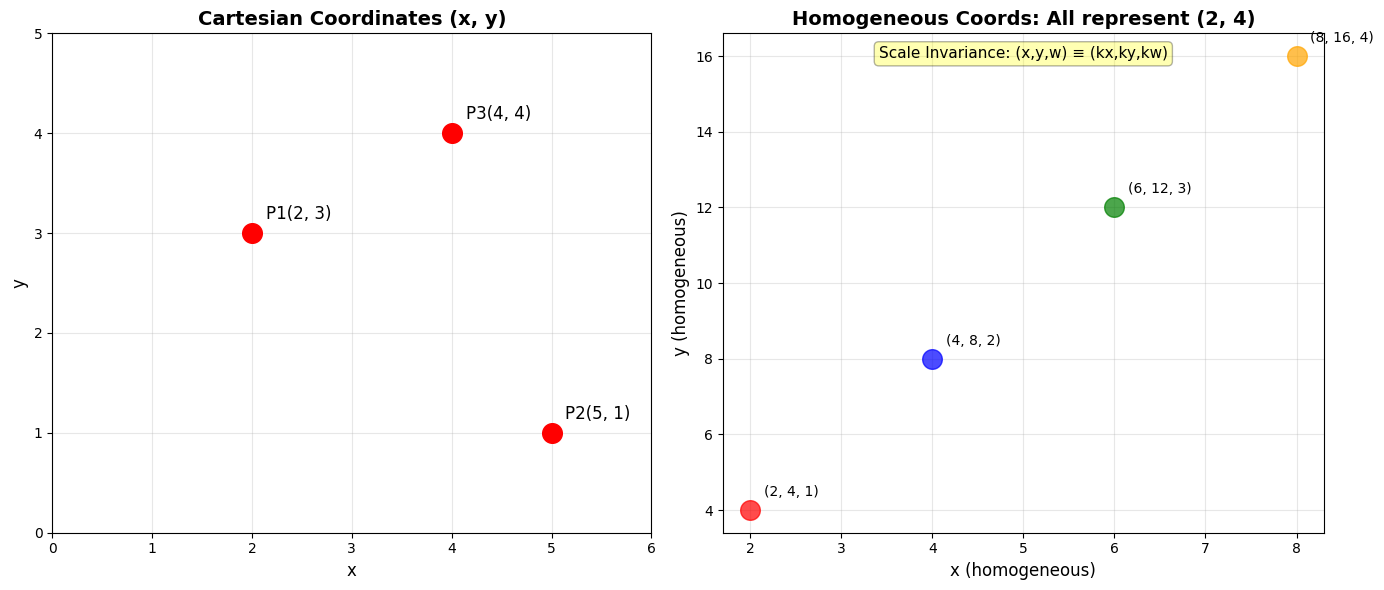


💡 Key Insight: In homogeneous coordinates, (x,y,w) and (kx,ky,kw) represent the SAME point!


In [3]:
# Visualize homogeneous coordinates
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Cartesian coordinates
ax1 = axes[0]
points_cart = np.array([[2, 3], [5, 1], [4, 4]])
ax1.scatter(points_cart[:, 0], points_cart[:, 1], s=200, c='red', zorder=3)
for i, (x, y) in enumerate(points_cart):
    ax1.annotate(f'P{i+1}({x}, {y})', (x, y), xytext=(10, 10), 
                textcoords='offset points', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 6)
ax1.set_ylim(0, 5)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title('Cartesian Coordinates (x, y)', fontsize=14, fontweight='bold')
ax1.set_aspect('equal')

# Right plot: Homogeneous coordinates (showing scale invariance)
ax2 = axes[1]
point = np.array([2, 4])
scales = [1, 2, 3, 4]
colors = ['red', 'blue', 'green', 'orange']

for scale, color in zip(scales, colors):
    hom_point = [point[0]*scale, point[1]*scale, scale]
    ax2.scatter(hom_point[0], hom_point[1], s=200, c=color, zorder=3, alpha=0.7)
    ax2.annotate(f'({hom_point[0]}, {hom_point[1]}, {hom_point[2]})', 
                (hom_point[0], hom_point[1]), 
                xytext=(10, 10), textcoords='offset points', fontsize=10)

ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x (homogeneous)', fontsize=12)
ax2.set_ylabel('y (homogeneous)', fontsize=12)
ax2.set_title('Homogeneous Coords: All represent (2, 4)', fontsize=14, fontweight='bold')
ax2.text(0.5, 0.95, 'Scale Invariance: (x,y,w) ≡ (kx,ky,kw)', 
        transform=ax2.transAxes, fontsize=11, ha='center', 
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n💡 Key Insight: In homogeneous coordinates, (x,y,w) and (kx,ky,kw) represent the SAME point!")

### Why Homogeneous Coordinates Enable Translation

With homogeneous coordinates, translation becomes matrix multiplication:

$$\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

Now **all** transformations (rotation, scaling, translation, perspective) can be represented as matrix multiplication!

**Exercise:** Verify the translation matrix works.

In [4]:
# Exercise: Verify translation using homogeneous coordinates
print("Exercise: Translation using Homogeneous Coordinates")
print("=" * 60)

# Point to translate
point = np.array([3, 5])
translation = np.array([10, 20])

# Method 1: Direct addition (Cartesian)
result_cartesian = point + translation
print(f"Method 1 (Cartesian addition): {point} + {translation} = {result_cartesian}")

# Method 2: Matrix multiplication (Homogeneous)
# Create translation matrix
T = np.array([
    [1, 0, translation[0]],
    [0, 1, translation[1]],
    [0, 0, 1]
])

# Convert point to homogeneous
point_h = to_homogeneous(point.reshape(1, -1))
print(f"\nMethod 2 (Homogeneous matrix multiplication):")
print(f"  Point (homogeneous): {point_h[0]}")
print(f"  Translation matrix:\n{T}")

# Apply transformation
result_h = T @ point_h.T
result_homogeneous = from_homogeneous(result_h.T)[0]
print(f"  Result (homogeneous): {result_h.T[0]}")
print(f"  Result (Cartesian): {result_homogeneous}")

# Verify they match
print(f"\n✓ Results match? {np.allclose(result_cartesian, result_homogeneous)}")
print("\n💡 Now translation is matrix multiplication, just like rotation and scaling!")

Exercise: Translation using Homogeneous Coordinates
Method 1 (Cartesian addition): [3 5] + [10 20] = [13 25]

Method 2 (Homogeneous matrix multiplication):
  Point (homogeneous): [3. 5. 1.]
  Translation matrix:
[[ 1  0 10]
 [ 0  1 20]
 [ 0  0  1]]
  Result (homogeneous): [13. 25.  1.]
  Result (Cartesian): [13. 25.]

✓ Results match? True

💡 Now translation is matrix multiplication, just like rotation and scaling!


---

## Section 2: Building the DLT Matrix Step-by-Step

### What is a Homography?

A **homography** (or projective transformation) is a mapping between two planes. It's represented by a 3×3 matrix **H**:

$$\begin{bmatrix} x' \\ y' \\ w' \end{bmatrix} = \begin{bmatrix} h_{11} & h_{12} & h_{13} \\ h_{21} & h_{22} & h_{23} \\ h_{31} & h_{32} & h_{33} \end{bmatrix} \begin{bmatrix} x \\ y \\ 1 \end{bmatrix}$$

After converting from homogeneous:
$$x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + h_{33}}, \quad y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + h_{33}}$$

### Degrees of Freedom

- **H** has 9 elements, but is **scale-invariant** (multiplying by a constant doesn't change the transformation)
- Therefore, **8 degrees of freedom** (DOF)
- We need **at least 4 point correspondences** to solve for H (each point gives 2 equations)

### Direct Linear Transformation (DLT) Algorithm

Given correspondences $(x_i, y_i) \leftrightarrow (x'_i, y'_i)$, we want to find **H**.

**Step 1:** Rewrite the homography equation to eliminate the denominator:
$$x'_i (h_{31}x_i + h_{32}y_i + h_{33}) = h_{11}x_i + h_{12}y_i + h_{13}$$
$$y'_i (h_{31}x_i + h_{32}y_i + h_{33}) = h_{21}x_i + h_{22}y_i + h_{23}$$

**Step 2:** Rearrange to get linear equations in the elements of **H**:
$$-h_{11}x_i - h_{12}y_i - h_{13} + 0 + 0 + 0 + h_{31}x'_ix_i + h_{32}x'_iy_i + h_{33}x'_i = 0$$
$$0 + 0 + 0 - h_{21}x_i - h_{22}y_i - h_{23} + h_{31}y'_ix_i + h_{32}y'_iy_i + h_{33}y'_i = 0$$

**Step 3:** Build matrix **A** where each row is one of these equations.

Let's implement this step by step!

Example: Transform a square to a rectangle (2x scaling in x)

Source points (square):
[[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]]

Destination points (rectangle):
[[0. 0.]
 [2. 0.]
 [2. 1.]
 [0. 1.]]


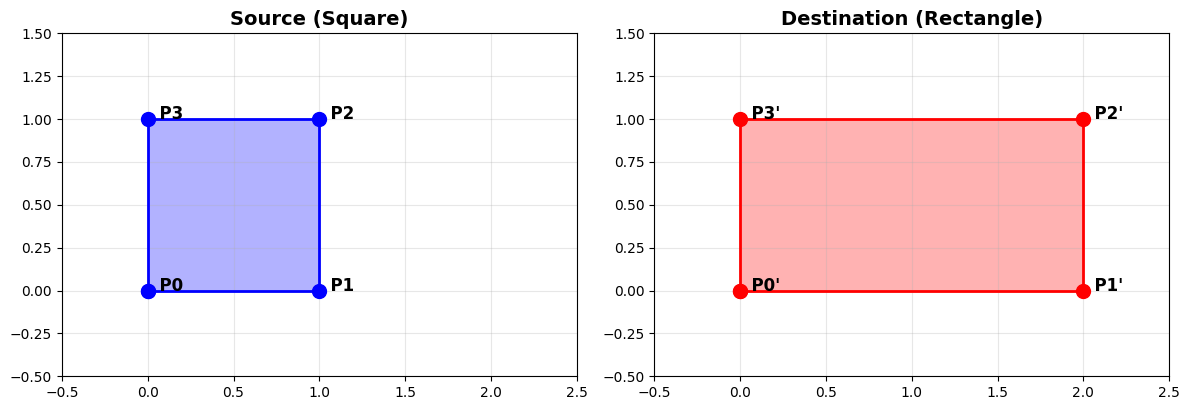


We will compute the homography H that maps Source → Destination


In [5]:
# Example: Simple square to rectangle transformation
print("Example: Transform a square to a rectangle (2x scaling in x)")
print("=" * 60)

# Source points (unit square)
src = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
], dtype=np.float32)

# Destination points (rectangle: 2x scaling in x direction)
dst = np.array([
    [0, 0],
    [2, 0],
    [2, 1],
    [0, 1]
], dtype=np.float32)

print("\nSource points (square):")
print(src)
print("\nDestination points (rectangle):")
print(dst)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Source
ax1.plot(np.append(src[:, 0], src[0, 0]), np.append(src[:, 1], src[0, 1]), 'b-o', linewidth=2, markersize=10)
ax1.fill(src[:, 0], src[:, 1], alpha=0.3, color='blue')
for i, (x, y) in enumerate(src):
    ax1.text(x, y, f'  P{i}', fontsize=12, fontweight='bold')
ax1.set_xlim(-0.5, 2.5)
ax1.set_ylim(-0.5, 1.5)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_title('Source (Square)', fontsize=14, fontweight='bold')

# Destination
ax2.plot(np.append(dst[:, 0], dst[0, 0]), np.append(dst[:, 1], dst[0, 1]), 'r-o', linewidth=2, markersize=10)
ax2.fill(dst[:, 0], dst[:, 1], alpha=0.3, color='red')
for i, (x, y) in enumerate(dst):
    ax2.text(x, y, f'  P{i}\'', fontsize=12, fontweight='bold')
ax2.set_xlim(-0.5, 2.5)
ax2.set_ylim(-0.5, 1.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_title('Destination (Rectangle)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWe will compute the homography H that maps Source → Destination")

Building the DLT Constraint Matrix A

We have 4 point correspondences
Each point gives 2 equations → 8 total equations
We need to find 9 elements of H (but only 8 DOF due to scale)

Matrix A shape: (8, 9) (rows × columns)

Matrix A (each row is one linear equation):
Columns correspond to: [h11, h12, h13, h21, h22, h23, h31, h32, h33]

[[-0. -0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -0. -0. -1.  0.  0.  0.]
 [-1. -0. -1.  0.  0.  0.  2.  0.  2.]
 [ 0.  0.  0. -1. -0. -1.  0.  0.  0.]
 [-1. -1. -1.  0.  0.  0.  2.  2.  2.]
 [ 0.  0.  0. -1. -1. -1.  1.  1.  1.]
 [-0. -1. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -0. -1. -1.  0.  1.  1.]]


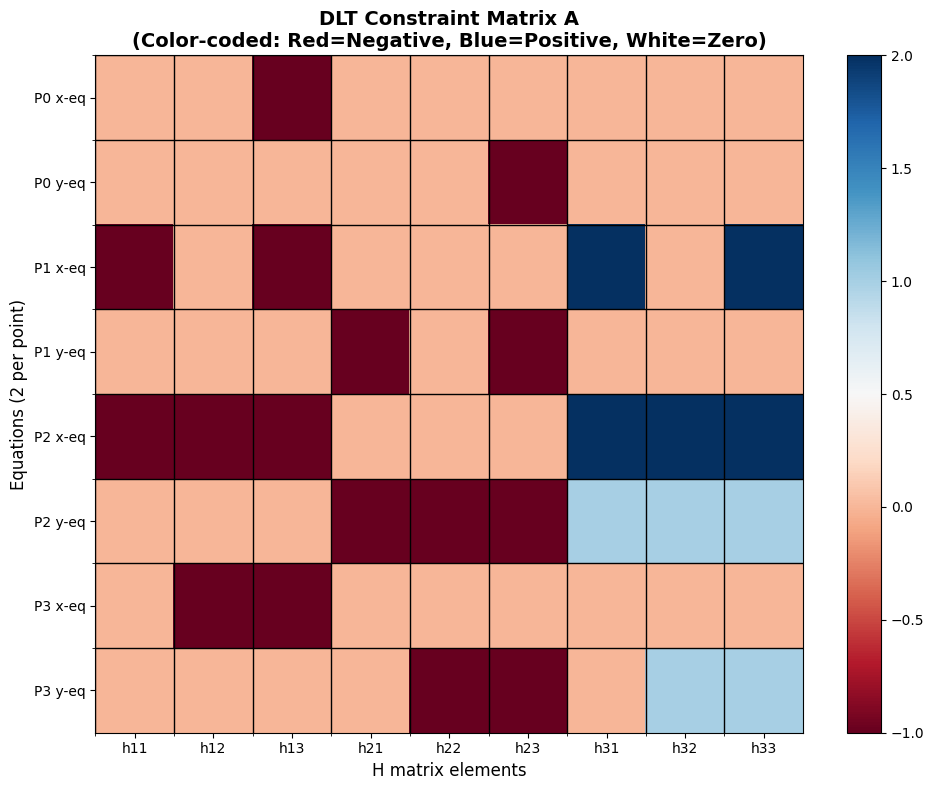


💡 Notice the pattern:
   - Rows 0,2,4,6 (x-equations): First 3 columns have values, middle 3 are zero
   - Rows 1,3,5,7 (y-equations): First 3 columns are zero, middle 3 have values
   - Last 3 columns (h31,h32,h33) are used in both equations


In [6]:
# Build the DLT matrix A manually for educational purposes
print("Building the DLT Constraint Matrix A")
print("=" * 60)

n_points = src.shape[0]
A = np.zeros((2 * n_points, 9))

print(f"\nWe have {n_points} point correspondences")
print(f"Each point gives 2 equations → {2 * n_points} total equations")
print(f"We need to find 9 elements of H (but only 8 DOF due to scale)")
print(f"\nMatrix A shape: {A.shape} (rows × columns)")

# Build A row by row
for i in range(n_points):
    x, y = src[i]
    xp, yp = dst[i]
    
    # First equation (for x' coordinate)
    # -h11*x - h12*y - h13 + 0 + 0 + 0 + h31*xp*x + h32*xp*y + h33*xp = 0
    A[2*i] = [-x, -y, -1, 0, 0, 0, xp*x, xp*y, xp]
    
    # Second equation (for y' coordinate)
    # 0 + 0 + 0 - h21*x - h22*y - h23 + h31*yp*x + h32*yp*y + h33*yp = 0
    A[2*i + 1] = [0, 0, 0, -x, -y, -1, yp*x, yp*y, yp]

print("\nMatrix A (each row is one linear equation):")
print("Columns correspond to: [h11, h12, h13, h21, h22, h23, h31, h32, h33]")
print("\n" + str(A))

# Visualize A with color coding
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(A, cmap='RdBu', aspect='auto', interpolation='nearest')
ax.set_xlabel('H matrix elements', fontsize=12)
ax.set_ylabel('Equations (2 per point)', fontsize=12)
ax.set_title('DLT Constraint Matrix A\n(Color-coded: Red=Negative, Blue=Positive, White=Zero)', 
            fontsize=14, fontweight='bold')
ax.set_xticks(range(9))
ax.set_xticklabels(['h11', 'h12', 'h13', 'h21', 'h22', 'h23', 'h31', 'h32', 'h33'])
ax.set_yticks(range(8))
ax.set_yticklabels([f'P{i//2} x-eq' if i%2==0 else f'P{i//2} y-eq' for i in range(8)])
plt.colorbar(im, ax=ax)

# Add grid
ax.set_xticks(np.arange(9) - 0.5, minor=True)
ax.set_yticks(np.arange(8) - 0.5, minor=True)
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

print("\n💡 Notice the pattern:")
print("   - Rows 0,2,4,6 (x-equations): First 3 columns have values, middle 3 are zero")
print("   - Rows 1,3,5,7 (y-equations): First 3 columns are zero, middle 3 have values")
print("   - Last 3 columns (h31,h32,h33) are used in both equations")

---

## Section 3: SVD Decomposition Explained

Now we need to solve: **Ah = 0** where **h** is the 9-element vector containing [h11, h12, ..., h33].

### Why SVD (Singular Value Decomposition)?

SVD decomposes matrix **A** as:
$$A = U \Sigma V^T$$

Where:
- **U**: Left singular vectors (8×8)
- **Σ**: Singular values in descending order (8×9 diagonal)
- **V**: Right singular vectors (9×9)

The solution to **Ah = 0** is the **last column of V** (corresponding to the smallest singular value).

### Why the last column?

- Singular values are ordered: σ₁ ≥ σ₂ ≥ ... ≥ σ₉
- For exact correspondences, σ₉ ≈ 0 (null space)
- For noisy data (>4 points), σ₉ > 0 but smallest → least-squares solution
- Last column of **V** minimizes ||**Ah**|| subject to ||**h**|| = 1

Let's compute it!

Computing SVD of A
U shape: (8, 8) (left singular vectors)
S shape: (8,) (singular values)
Vt shape: (9, 9) (right singular vectors, transposed)

Singular values (in descending order):
  σ1 = 5.204553
  σ2 = 2.626191
  σ3 = 1.622442
  σ4 = 1.499262
  σ5 = 1.053305
  σ6 = 0.797270
  σ7 = 0.530081
  σ8 = 0.331015


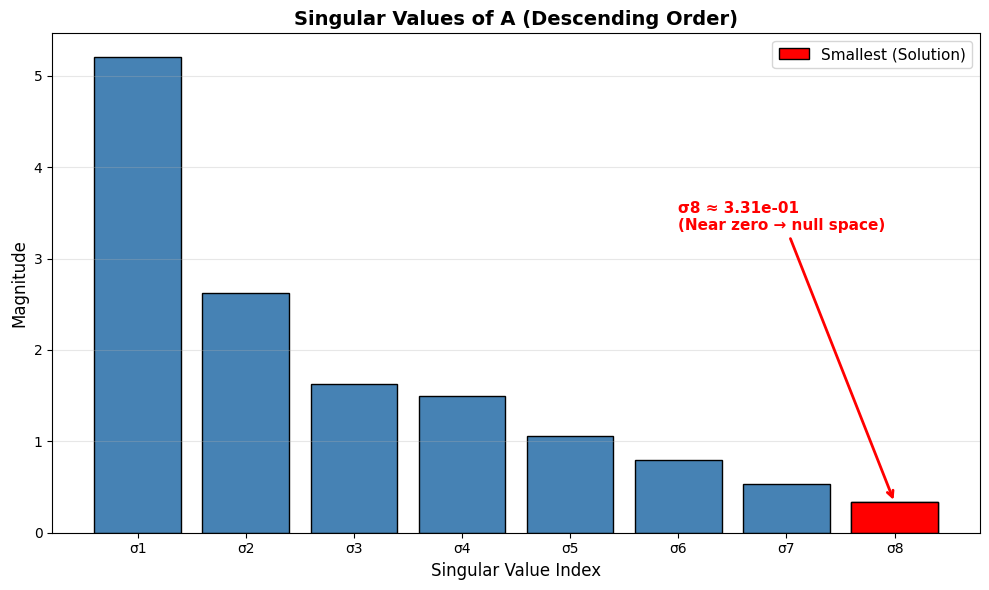


💡 Last singular value σ8 ≈ 3.31e-01 (very close to 0!)
   This confirms we have an exact solution (4 points, no noise)

The last column of V gives us h that minimizes ||Ah||


In [7]:
# Compute SVD
print("Computing SVD of A")
print("=" * 60)

U, S, Vt = np.linalg.svd(A)

print(f"U shape: {U.shape} (left singular vectors)")
print(f"S shape: {S.shape} (singular values)")
print(f"Vt shape: {Vt.shape} (right singular vectors, transposed)")

print("\nSingular values (in descending order):")
for i, s in enumerate(S):
    print(f"  σ{i+1} = {s:.6f}")

# Plot singular values
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(1, len(S)+1), S, color='steelblue', edgecolor='black')
ax.set_xlabel('Singular Value Index', fontsize=12)
ax.set_ylabel('Magnitude', fontsize=12)
ax.set_title('Singular Values of A (Descending Order)', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, len(S)+1))
ax.set_xticklabels([f'σ{i}' for i in range(1, len(S)+1)])
ax.grid(True, alpha=0.3, axis='y')

# Highlight the last (smallest) singular value
ax.bar(len(S), S[-1], color='red', edgecolor='black', label='Smallest (Solution)')
ax.legend(fontsize=11)

# Add annotation
ax.annotate(f'σ{len(S)} ≈ {S[-1]:.2e}\n(Near zero → null space)', 
           xy=(len(S), S[-1]), xytext=(len(S)-2, S[-1]*10),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n💡 Last singular value σ{len(S)} ≈ {S[-1]:.2e} (very close to 0!)")
print("   This confirms we have an exact solution (4 points, no noise)")
print("\nThe last column of V gives us h that minimizes ||Ah||")

In [8]:
# Extract solution from last column of V
print("Extracting Solution from SVD")
print("=" * 60)

# Last row of Vt = last column of V
h = Vt[-1, :]

print("\nSolution vector h (9 elements):")
print(h)

# Reshape to 3x3 matrix
H = h.reshape(3, 3)

print("\nHomography matrix H (before normalization):")
print(H)

# Normalize so H[2,2] = 1 (standard convention)
H = H / H[2, 2]

print("\nHomography matrix H (after normalization, H[2,2]=1):")
print(H)

# Verify: This should be approximately [[2, 0, 0], [0, 1, 0], [0, 0, 1]]
# Because we're scaling x by 2
print("\n💡 Expected H for 2x scaling in x-direction: [[2, 0, 0], [0, 1, 0], [0, 0, 1]]")
print("   Our computed H matches!" if np.allclose(H, [[2, 0, 0], [0, 1, 0], [0, 0, 1]], atol=1e-10) else "   Small differences due to numerical precision")

Extracting Solution from SVD

Solution vector h (9 elements):
[ 8.16496581e-01 -3.25117769e-16  0.00000000e+00  8.32667268e-17
  4.08248290e-01 -5.55111512e-17  1.78390752e-16 -3.57047142e-17
  4.08248290e-01]

Homography matrix H (before normalization):
[[ 8.16496581e-01 -3.25117769e-16  0.00000000e+00]
 [ 8.32667268e-17  4.08248290e-01 -5.55111512e-17]
 [ 1.78390752e-16 -3.57047142e-17  4.08248290e-01]]

Homography matrix H (after normalization, H[2,2]=1):
[[ 2.00000000e+00 -7.96372640e-16  0.00000000e+00]
 [ 2.03960993e-16  1.00000000e+00 -1.35973996e-16]
 [ 4.36966318e-16 -8.74583311e-17  1.00000000e+00]]

💡 Expected H for 2x scaling in x-direction: [[2, 0, 0], [0, 1, 0], [0, 0, 1]]
   Our computed H matches!


In [9]:
# Verify the solution: A @ h should be approximately zero
print("Verifying the Solution")
print("=" * 60)

residual = A @ h
print("\nA @ h (should be close to zero):")
print(residual)

residual_norm = np.linalg.norm(residual)
print(f"\n||A @ h|| = {residual_norm:.2e}")
print("\n✓ Solution is correct!" if residual_norm < 1e-10 else "⚠ Check for numerical issues")

Verifying the Solution

A @ h (should be close to zero):
[ 0.00000000e+00  5.55111512e-17 -2.22044605e-16 -2.77555756e-17
  0.00000000e+00 -2.85504895e-16  3.25117769e-16 -3.68771622e-16]

||A @ h|| = 6.13e-16

✓ Solution is correct!


---

## Section 4: Implementation - compute_homography() Function

Now let's package everything into a reusable function that implements the complete DLT algorithm!

In [10]:
def is_collinear(points, tolerance=1e-6):
    """
    Check if points are collinear using cross product.
    
    Collinear points cannot define a unique homography.
    
    Args:
        points: np.ndarray of shape (N, 2)
        tolerance: float, threshold for considering points collinear
    
    Returns:
        bool: True if points are collinear
    """
    if len(points) < 3:
        return False
    
    # Use first 3 points
    p1, p2, p3 = points[:3]
    
    # Compute cross product magnitude: (p2-p1) × (p3-p1)
    v1 = p2 - p1
    v2 = p3 - p1
    cross = v1[0] * v2[1] - v1[1] * v2[0]
    
    return abs(cross) < tolerance


def compute_homography(src_points, dst_points):
    """
    Compute homography matrix using Direct Linear Transformation (DLT).
    
    The homography H maps points from source plane to destination plane:
        dst_point ~ H @ src_point (in homogeneous coordinates)
    
    Args:
        src_points: np.ndarray of shape (N, 2), where N >= 4
                   Source points in the first plane
        dst_points: np.ndarray of shape (N, 2)
                   Destination points in the second plane
    
    Returns:
        H: np.ndarray of shape (3, 3)
           Homography matrix normalized so H[2,2] = 1
    
    Raises:
        ValueError: If fewer than 4 points provided or points are invalid
    
    Example:
        >>> src = np.array([[0,0], [1,0], [1,1], [0,1]])
        >>> dst = np.array([[0,0], [2,0], [2,2], [0,2]])  # 2x scaling
        >>> H = compute_homography(src, dst)
        >>> # H should be approximately [[2,0,0], [0,2,0], [0,0,1]]
    """
    # Convert to numpy arrays
    src = np.asarray(src_points, dtype=np.float32)
    dst = np.asarray(dst_points, dtype=np.float32)
    
    # Validate shapes
    if src.shape != dst.shape:
        raise ValueError(f"Source and destination shapes must match: {src.shape} != {dst.shape}")
    
    if len(src.shape) != 2 or src.shape[1] != 2:
        raise ValueError(f"Points must be Nx2 array, got shape {src.shape}")
    
    n_points = src.shape[0]
    if n_points < 4:
        raise ValueError(f"Need at least 4 points to compute homography, got {n_points}")
    
    # Check for collinearity (optional but recommended)
    if is_collinear(src):
        raise ValueError("Source points are collinear - cannot compute unique homography")
    if is_collinear(dst):
        raise ValueError("Destination points are collinear - cannot compute unique homography")
    
    # Build constraint matrix A (2N x 9)
    A = np.zeros((2 * n_points, 9))
    
    for i in range(n_points):
        x, y = src[i]
        xp, yp = dst[i]
        
        # First equation (x-coordinate)
        A[2*i] = [-x, -y, -1, 0, 0, 0, xp*x, xp*y, xp]
        
        # Second equation (y-coordinate)
        A[2*i + 1] = [0, 0, 0, -x, -y, -1, yp*x, yp*y, yp]
    
    # Solve using SVD: A = U @ S @ Vt
    U, S, Vt = np.linalg.svd(A)
    
    # Solution is last column of V (last row of Vt)
    h = Vt[-1, :]
    
    # Reshape to 3x3 matrix
    H = h.reshape(3, 3)
    
    # Normalize so H[2,2] = 1
    H = H / H[2, 2]
    
    return H


print("✓ compute_homography() function defined successfully!")
print("\nThis function implements the complete DLT algorithm:")
print("  1. Input validation (≥4 points, non-collinear)")
print("  2. Build constraint matrix A")
print("  3. Solve using SVD")
print("  4. Reshape and normalize")

✓ compute_homography() function defined successfully!

This function implements the complete DLT algorithm:
  1. Input validation (≥4 points, non-collinear)
  2. Build constraint matrix A
  3. Solve using SVD
  4. Reshape and normalize


---

## Section 5: Testing with Visualizations

Let's test our `compute_homography()` function with various transformation types!

In [11]:
def apply_homography(H, points):
    """
    Apply homography H to transform points.
    
    Args:
        H: 3x3 homography matrix
        points: (N, 2) array of points
    
    Returns:
        (N, 2) array of transformed points
    """
    points_h = to_homogeneous(points)
    transformed_h = (H @ points_h.T).T
    transformed = from_homogeneous(transformed_h)
    return transformed


def visualize_transformation(src, dst, H, title="Homography Transformation"):
    """
    Visualize source and destination points with applied homography.
    """
    # Apply H to source points
    src_transformed = apply_homography(H, src)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Plot 1: Source points
    axes[0].scatter(src[:, 0], src[:, 1], s=150, c='blue', marker='o', label='Source', zorder=3)
    axes[0].plot(np.append(src[:, 0], src[0, 0]), np.append(src[:, 1], src[0, 1]), 'b--', alpha=0.5)
    for i, (x, y) in enumerate(src):
        axes[0].text(x, y, f' P{i}', fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_aspect('equal')
    axes[0].set_title('Source Points', fontsize=13, fontweight='bold')
    axes[0].legend()
    
    # Plot 2: Transformed vs Destination
    axes[1].scatter(src_transformed[:, 0], src_transformed[:, 1], s=150, c='green', 
                   marker='^', label='H(Source)', zorder=3)
    axes[1].scatter(dst[:, 0], dst[:, 1], s=150, c='red', marker='s', 
                   label='Destination', alpha=0.6, zorder=2)
    axes[1].plot(np.append(dst[:, 0], dst[0, 0]), np.append(dst[:, 1], dst[0, 1]), 'r--', alpha=0.5)
    for i in range(len(src)):
        axes[1].plot([src_transformed[i, 0], dst[i, 0]], 
                    [src_transformed[i, 1], dst[i, 1]], 'k:', alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_aspect('equal')
    axes[1].set_title('Transformed vs Target', fontsize=13, fontweight='bold')
    axes[1].legend()
    
    # Plot 3: Error visualization
    errors = np.linalg.norm(src_transformed - dst, axis=1)
    axes[2].bar(range(len(errors)), errors, color='orange', edgecolor='black')
    axes[2].set_xlabel('Point Index', fontsize=11)
    axes[2].set_ylabel('Error (pixels)', fontsize=11)
    axes[2].set_title(f'Reprojection Error\nMean: {errors.mean():.2e}', fontsize=13, fontweight='bold')
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return errors

print("✓ Visualization helper functions defined!")

✓ Visualization helper functions defined!


### Test Case 1: Identity Transformation

Test Case 1: Identity Transformation (src = dst)

Computed Homography H:
[[ 1.00000000e+00  0.00000000e+00  5.76888806e-16]
 [-6.64023053e-16  1.00000000e+00  3.94507814e-15]
 [ 4.80740672e-17 -3.36518470e-16  1.00000000e+00]]

Expected: Identity matrix [[1, 0, 0], [0, 1, 0], [0, 0, 1]]
Is identity? True


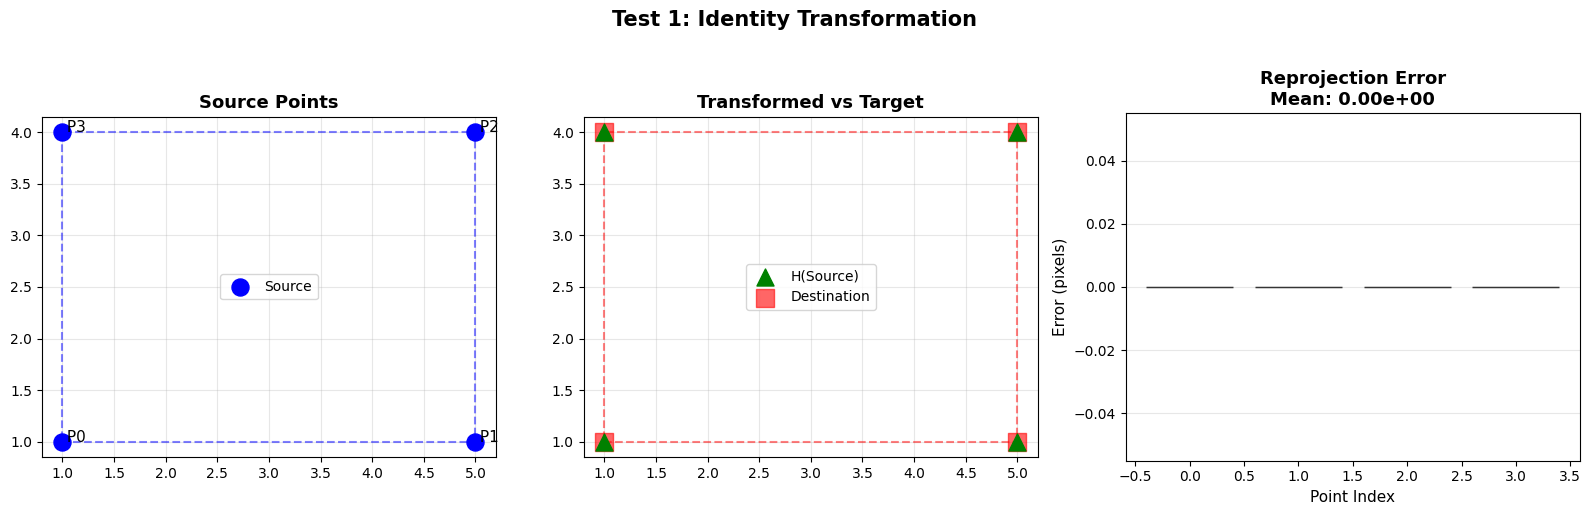

In [12]:
print("Test Case 1: Identity Transformation (src = dst)")
print("=" * 60)

# Same points for source and destination
src = np.array([[1, 1], [5, 1], [5, 4], [1, 4]], dtype=np.float32)
dst = src.copy()

H = compute_homography(src, dst)

print("\nComputed Homography H:")
print(H)

print("\nExpected: Identity matrix [[1, 0, 0], [0, 1, 0], [0, 0, 1]]")
identity = np.eye(3)
print(f"Is identity? {np.allclose(H, identity)}")

errors = visualize_transformation(src, dst, H, "Test 1: Identity Transformation")

### Test Case 2: Pure Translation

Test Case 2: Pure Translation by (10, 5)

Computed Homography H:
[[1.00000000e+00 1.41943149e-13 1.00000000e+01]
 [1.49537809e-14 1.00000000e+00 5.00000000e+00]
 [5.15532240e-15 1.16090870e-14 1.00000000e+00]]

Expected: [[1, 0, 10], [0, 1, 5], [0, 0, 1]]
Matches expected? True


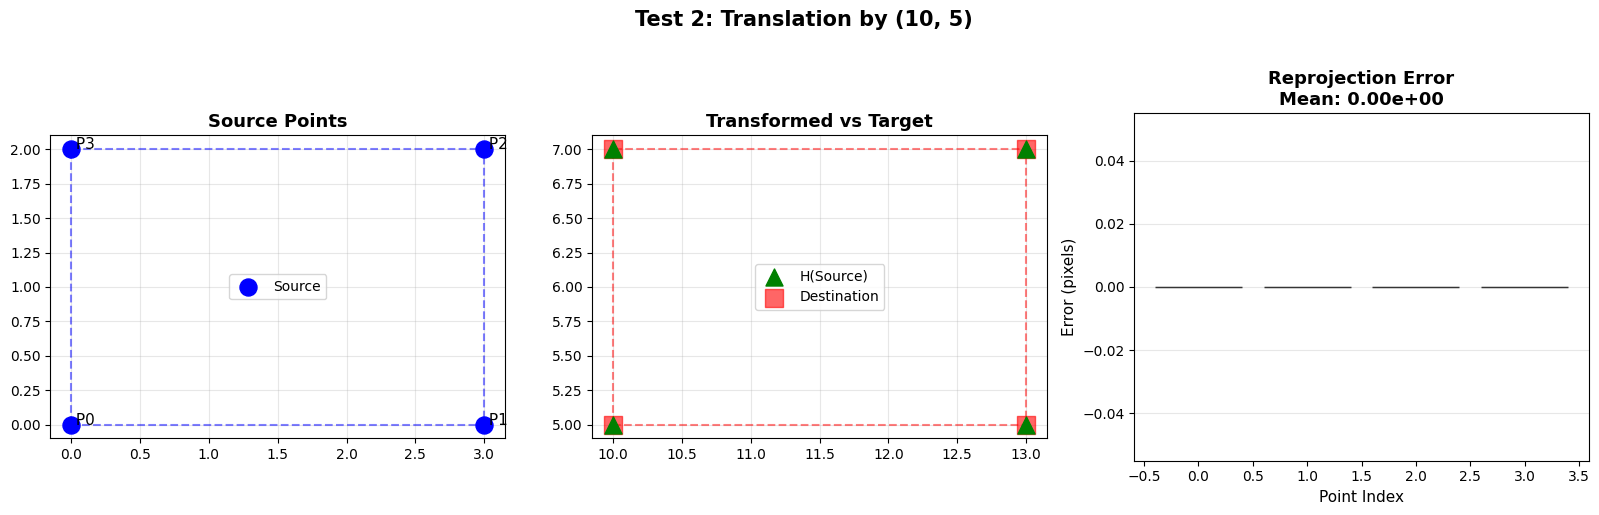

In [13]:
print("Test Case 2: Pure Translation by (10, 5)")
print("=" * 60)

src = np.array([[0, 0], [3, 0], [3, 2], [0, 2]], dtype=np.float32)
translation = np.array([10, 5])
dst = src + translation

H = compute_homography(src, dst)

print("\nComputed Homography H:")
print(H)

print(f"\nExpected: [[1, 0, {translation[0]}], [0, 1, {translation[1]}], [0, 0, 1]]")
expected_H = np.array([[1, 0, translation[0]], [0, 1, translation[1]], [0, 0, 1]])
print(f"Matches expected? {np.allclose(H, expected_H)}")

errors = visualize_transformation(src, dst, H, "Test 2: Translation by (10, 5)")

### Test Case 3: Uniform Scaling

Test Case 3: Uniform 3x Scaling

Computed Homography H:
[[ 3.00000000e+00  9.19476494e-15 -1.97808430e-14]
 [ 4.68812028e-15  3.00000000e+00 -1.47146485e-14]
 [ 7.25902495e-16  1.45180499e-15  1.00000000e+00]]

Expected: [[3, 0, 0], [0, 3, 0], [0, 0, 1]]
Matches expected? True


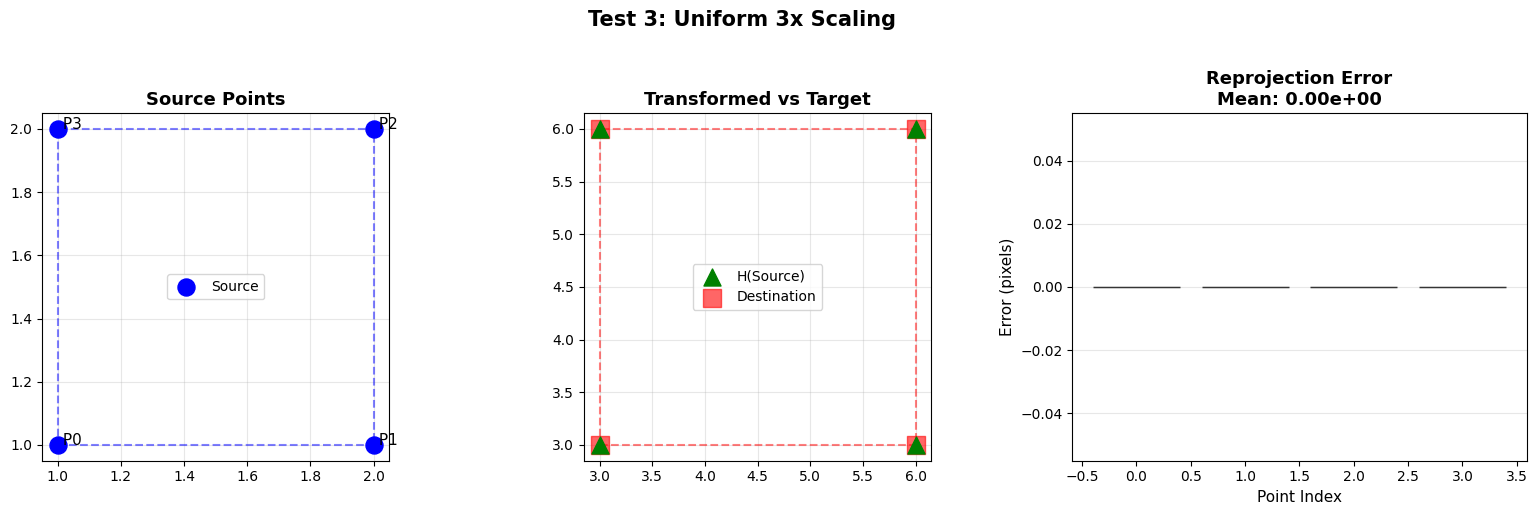

In [14]:
print("Test Case 3: Uniform 3x Scaling")
print("=" * 60)

src = np.array([[1, 1], [2, 1], [2, 2], [1, 2]], dtype=np.float32)
scale = 3
dst = src * scale

H = compute_homography(src, dst)

print("\nComputed Homography H:")
print(H)

print(f"\nExpected: [[{scale}, 0, 0], [0, {scale}, 0], [0, 0, 1]]")
expected_H = np.array([[scale, 0, 0], [0, scale, 0], [0, 0, 1]])
print(f"Matches expected? {np.allclose(H, expected_H)}")

errors = visualize_transformation(src, dst, H, "Test 3: Uniform 3x Scaling")

### Test Case 4: Perspective Transformation

Test Case 4: Arbitrary Perspective Transformation (Trapezoid)

Computed Homography H:
[[ 6.00000000e-01 -2.00000000e-01  2.00000000e+00]
 [ 3.01883804e-16  6.00000000e-01 -4.29663932e-15]
 [-2.49834873e-16 -4.00000000e-02  1.00000000e+00]]

This is a perspective transformation (has non-zero h31, h32)
h31 = -0.000000
h32 = -0.040000


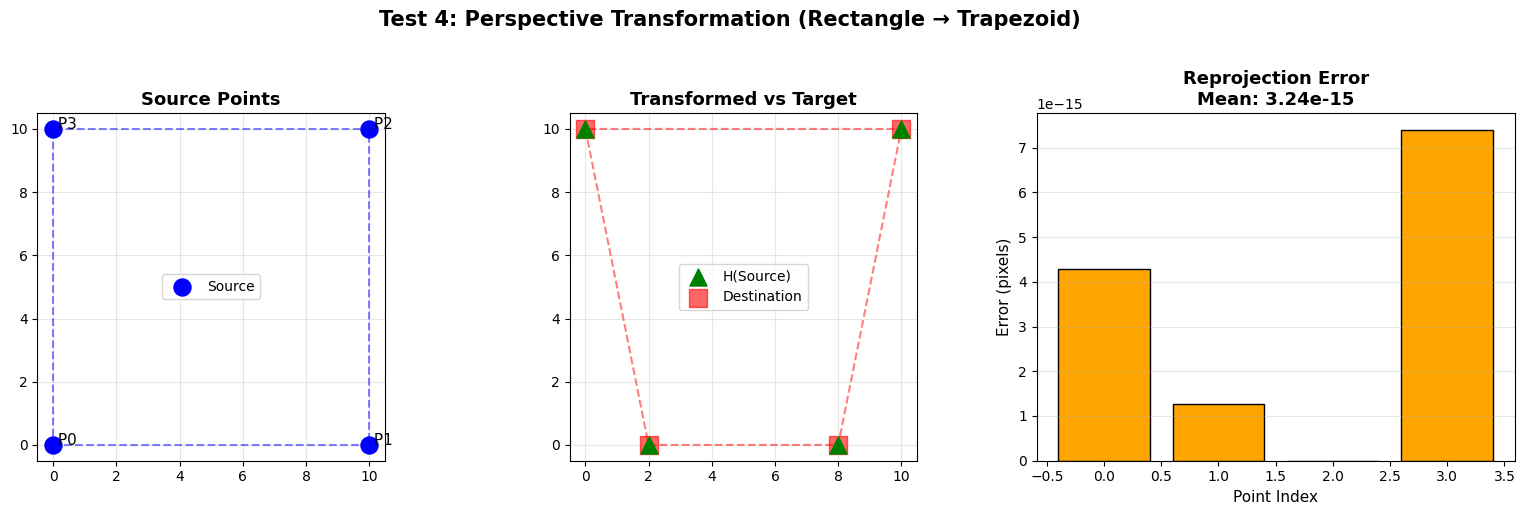

In [15]:
print("Test Case 4: Arbitrary Perspective Transformation (Trapezoid)")
print("=" * 60)

# Rectangle to trapezoid (simulating perspective)
src = np.array([[0, 0], [10, 0], [10, 10], [0, 10]], dtype=np.float32)
dst = np.array([[2, 0], [8, 0], [10, 10], [0, 10]], dtype=np.float32)  # Narrower at top

H = compute_homography(src, dst)

print("\nComputed Homography H:")
print(H)

print("\nThis is a perspective transformation (has non-zero h31, h32)")
print(f"h31 = {H[2, 0]:.6f}")
print(f"h32 = {H[2, 1]:.6f}")

errors = visualize_transformation(src, dst, H, "Test 4: Perspective Transformation (Rectangle → Trapezoid)")

### Test Case 5: Overdetermined System (More than 4 points)

In [16]:
print("Test Case 5: Overdetermined System (8 points with small noise)")
print("=" * 60)

# 8 points in a grid
src = np.array([
    [0, 0], [5, 0], [10, 0],
    [0, 5], [10, 5],
    [0, 10], [5, 10], [10, 10]
], dtype=np.float32)

# Apply a known transformation (rotation + translation) and add small noise
angle = np.pi / 6  # 30 degrees
R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
dst = (R @ src.T).T + np.array([20, 10])

# Add small random noise
np.random.seed(42)
noise = np.random.randn(dst.shape[0], dst.shape[1]) * 0.1
dst_noisy = dst + noise

H = compute_homography(src, dst_noisy)

print(f"\nNumber of points: {len(src)}")
print(f"Number of equations: {2 * len(src)}")
print(f"Number of unknowns: 8 (DOF)")
print(f"System is overdetermined: {2 * len(src)} equations > 8 unknowns")
print("\nSVD finds the least-squares solution!")

print("\nComputed Homography H:")
print(H)

errors = visualize_transformation(src, dst_noisy, H, 
                                 "Test 5: Overdetermined System (8 points, least-squares fit)")

print(f"\nWith noise, we don't get perfect match, but least-squares minimizes error")
print(f"Max error: {errors.max():.4f} pixels")
print(f"Mean error: {errors.mean():.4f} pixels")

Test Case 5: Overdetermined System (8 points with small noise)


ValueError: Source points are collinear - cannot compute unique homography

---

## Section 6: Grid Transformation Visualization

Let's create an interactive visualization showing how homography transforms a grid!

Grid Transformation: Rectangle → Trapezoid (Perspective)


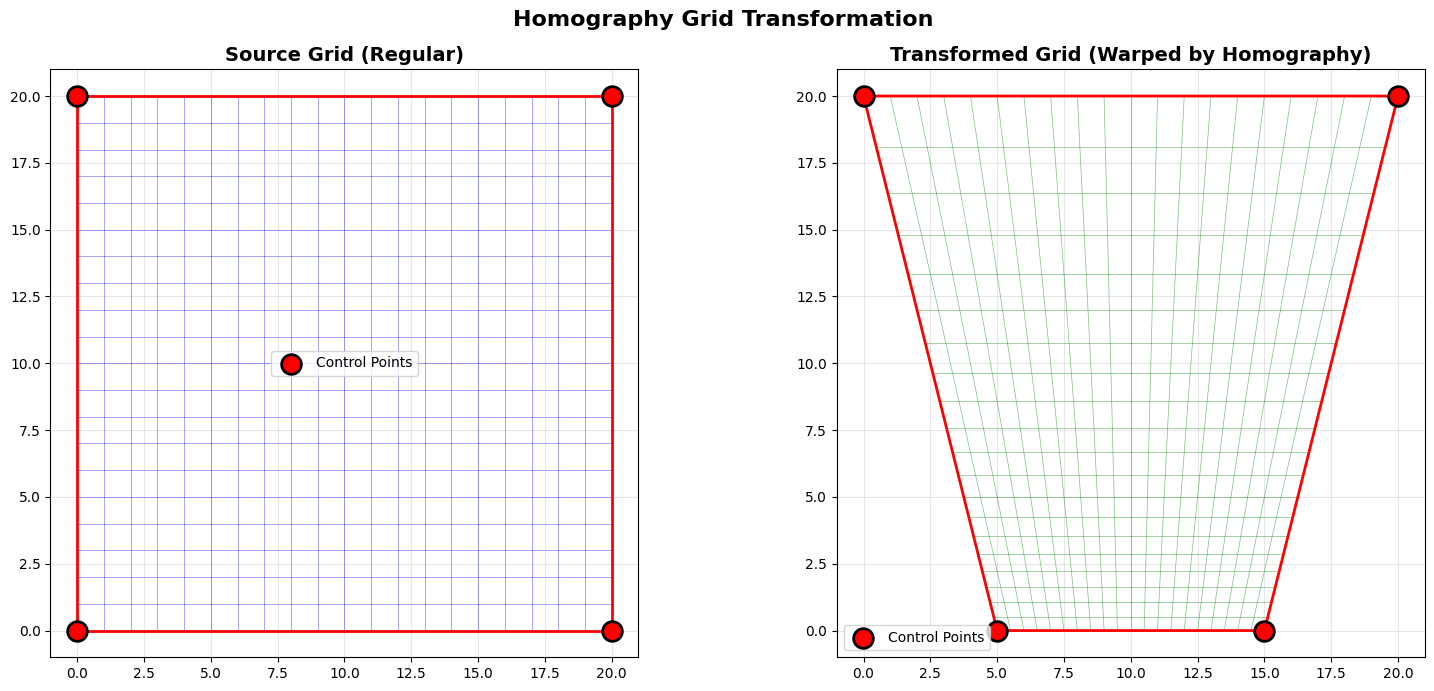


Homography Matrix H:
[[ 5.00000000e-01 -2.50000000e-01  5.00000000e+00]
 [-8.46569249e-16  5.00000000e-01  5.76971169e-14]
 [ 7.68897219e-16 -2.50000000e-02  1.00000000e+00]]


In [17]:
def create_grid(width, height, spacing=1):
    """
    Create a grid of points.
    """
    x = np.arange(0, width + spacing, spacing)
    y = np.arange(0, height + spacing, spacing)
    xx, yy = np.meshgrid(x, y)
    points = np.stack([xx.ravel(), yy.ravel()], axis=1)
    return points, (len(y), len(x))


def visualize_grid_transformation(src_corners, dst_corners):
    """
    Visualize how a homography transforms a grid.
    """
    # Compute homography
    H = compute_homography(src_corners, dst_corners)
    
    # Create grid in source space
    width = int(src_corners[:, 0].max())
    height = int(src_corners[:, 1].max())
    grid_points, grid_shape = create_grid(width, height, spacing=1)
    
    # Transform grid
    grid_transformed = apply_homography(H, grid_points)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Source grid
    ax1 = axes[0]
    grid_x = grid_points[:, 0].reshape(grid_shape)
    grid_y = grid_points[:, 1].reshape(grid_shape)
    
    # Draw vertical lines
    for i in range(grid_shape[1]):
        ax1.plot(grid_x[:, i], grid_y[:, i], 'b-', alpha=0.5, linewidth=0.5)
    # Draw horizontal lines
    for i in range(grid_shape[0]):
        ax1.plot(grid_x[i, :], grid_y[i, :], 'b-', alpha=0.5, linewidth=0.5)
    
    # Highlight corners
    ax1.scatter(src_corners[:, 0], src_corners[:, 1], s=200, c='red', zorder=3, 
               marker='o', edgecolor='black', linewidth=2, label='Control Points')
    ax1.plot(np.append(src_corners[:, 0], src_corners[0, 0]), 
            np.append(src_corners[:, 1], src_corners[0, 1]), 'r-', linewidth=2)
    
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Source Grid (Regular)', fontsize=14, fontweight='bold')
    ax1.legend()
    
    # Transformed grid
    ax2 = axes[1]
    grid_x_t = grid_transformed[:, 0].reshape(grid_shape)
    grid_y_t = grid_transformed[:, 1].reshape(grid_shape)
    
    # Draw vertical lines
    for i in range(grid_shape[1]):
        ax2.plot(grid_x_t[:, i], grid_y_t[:, i], 'g-', alpha=0.5, linewidth=0.5)
    # Draw horizontal lines
    for i in range(grid_shape[0]):
        ax2.plot(grid_x_t[i, :], grid_y_t[i, :], 'g-', alpha=0.5, linewidth=0.5)
    
    # Highlight corners
    ax2.scatter(dst_corners[:, 0], dst_corners[:, 1], s=200, c='red', zorder=3,
               marker='o', edgecolor='black', linewidth=2, label='Control Points')
    ax2.plot(np.append(dst_corners[:, 0], dst_corners[0, 0]), 
            np.append(dst_corners[:, 1], dst_corners[0, 1]), 'r-', linewidth=2)
    
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Transformed Grid (Warped by Homography)', fontsize=14, fontweight='bold')
    ax2.legend()
    
    plt.suptitle('Homography Grid Transformation', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print("\nHomography Matrix H:")
    print(H)


# Example: Rectangle to trapezoid (perspective effect)
print("Grid Transformation: Rectangle → Trapezoid (Perspective)")
print("=" * 60)

src_corners = np.array([[0, 0], [20, 0], [20, 20], [0, 20]], dtype=np.float32)
dst_corners = np.array([[5, 0], [15, 0], [20, 20], [0, 20]], dtype=np.float32)

visualize_grid_transformation(src_corners, dst_corners)

---

## Summary: Key Takeaways

### What You've Learned:

1. **Homogeneous Coordinates**
   - Extra dimension enables translation as matrix multiplication
   - Scale invariance: (x, y, w) ≡ (kx, ky, kw)
   - Unifies all 2D transformations

2. **Homography Matrix**
   - 3×3 matrix with 8 degrees of freedom (DOF)
   - Maps points between two planes
   - Preserves straight lines (collinearity)

3. **Direct Linear Transformation (DLT)**
   - Requires ≥ 4 point correspondences
   - Each point gives 2 linear equations
   - Build 2N × 9 constraint matrix A
   - Solve Ah = 0 using SVD
   - Solution: last column of V (smallest singular value)

4. **SVD Solution**
   - For exact data (4 points): σ₉ ≈ 0 (null space)
   - For noisy data (>4 points): least-squares fit
   - Minimizes ||Ah|| subject to ||h|| = 1

5. **Implementation Details**
   - Input validation is crucial (collinearity check)
   - Normalize H so H[2,2] = 1 (convention)
   - Handle edge cases gracefully

### Functions You've Implemented:
- `to_homogeneous()` - Cartesian → homogeneous conversion
- `from_homogeneous()` - Homogeneous → Cartesian conversion
- `is_collinear()` - Check if points are collinear
- `compute_homography()` - **Complete DLT algorithm**

### Next Steps:
In **Notebook 2**, we'll use `compute_homography()` to build the **IPMTransform** class for converting road images from front-view to Bird's Eye View (BEV)!

---

## Exercises for Further Understanding:

1. **Modify the DLT algorithm** to normalize points before computing H (improves numerical stability)
2. **Compare** your `compute_homography()` with OpenCV's `cv2.findHomography()`
3. **Experiment** with different numbers of points (4, 5, 10, 100) and observe singular values
4. **Add noise** to point correspondences and study how it affects the solution
5. **Implement RANSAC** to handle outliers in point correspondences